In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Add project root to sys.path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from scripts.preprocessing import AutomatedPreprocessor

#here we import and split the data
df = pd.read_csv("../data/mock/new/data.csv")

#TODO we should consider where to drop the unnecessary columns

TARGET_COLUMN = "rating"
columns_to_ignore = [TARGET_COLUMN, "timePeriod", "session_id", "sent_at", "date", "Date", "id"]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Test Shape: {X_test_processed.shape}")

Processed Train Shape: (1704, 9)
Processed Test Shape: (533, 9)


Best Parameters: {'alpha': 0.001, 'l1_ratio': 0.3}

Generalized Linear Regression Results:
Mean Squared Error: 0.1690
R2 Score: 0.4479
Rounded Accuracy: 79.74%


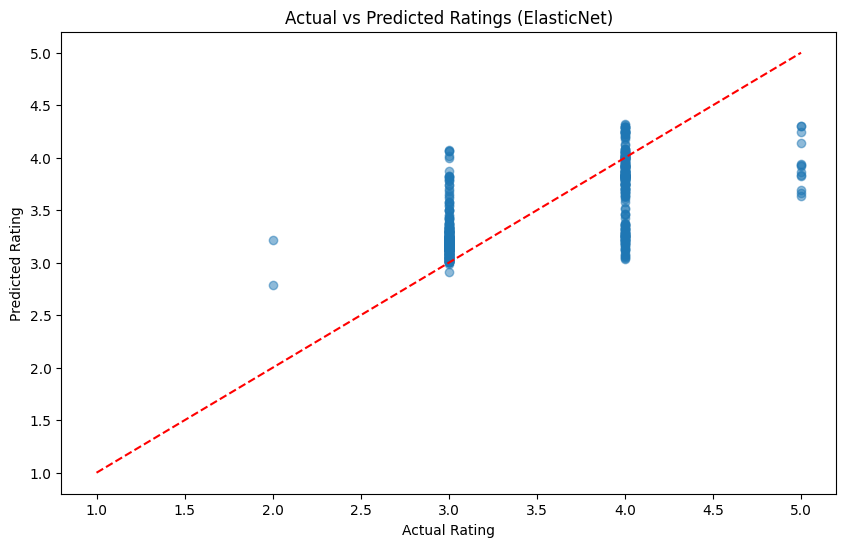

In [9]:
# Linear Regression with ElasticNet (Ridge + Lasso penalties)

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Hyperparameter tuning for both Ridge (L2) and Lasso (L1) aspects
# ElasticNet relies on 'alpha' (total penalty) and 'l1_ratio' (mix of L1 vs L2)
# l1_ratio=0 is pure Ridge, l1_ratio=1 is pure Lasso
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9] # 0 = Ridge, 1 = Lasso
}

elastic_net = ElasticNet(max_iter=10000)
grid_search = GridSearchCV(elastic_net, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 2. Predict on Test set
y_pred_continuous = best_model.predict(X_test_processed)

# 3. Handle bounds and round for classification-like accuracy
y_pred_clipped = np.clip(y_pred_continuous, 1, 5)
y_pred_rounded = np.round(y_pred_clipped).astype(int)

# 4. Metrics
mse = mean_squared_error(y_test, y_pred_continuous)
r2 = r2_score(y_test, y_pred_continuous)
acc = accuracy_score(y_test, y_pred_rounded)

print(f"\nGeneralized Linear Regression Results:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Rounded Accuracy: {acc * 100:.2f}%")

# Plotting actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_continuous, alpha=0.5)
plt.plot([1, 5], [1, 5], '--r')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (ElasticNet)")
plt.show()